# PocketToons Analytics Q&A Agent




## Section - 1
## Natural Language Interface for Product Analytics

### What I Built
An AI-powered analytics agent for PocketToons (a comic/webtoon streaming app).
Instead of writing SQL manually, anyone on the team can ask questions in plain English and get real answers backed by live data.

### Tech Stack
- **Database**: SQLite (4 tables, 5k+ rows synthetic data)
- **AI Model**: Llama 3.3 70B via Groq API (free)
- **Language**: Python
- **Libraries**: pandas, sqlite3, groq

### Files
- `generate_data.ipynb` → Creates synthetic database
- `sql_queries.ipynb` → Manual SQL queries (ground truth)
- `agent.ipynb` → AI agent (NL → SQL → Answer)
- `demo.ipynb` → This file — full walkthrough

In [1]:
!pip install groq -q

import sqlite3
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from groq import Groq






   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 4.6 MB/s eta 0:00:00


## Section 2 — Dataset Overview
Synthetic data representing a real webtoon streaming app.
4 tables designed to answer real product analytics questions.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving pockettoons.db to pockettoons.db


In [3]:
import os

print(os.listdir())

['.config', 'pockettoons.db', 'sample_data']


In [4]:
conn = sqlite3.connect("pockettoons.db")

print(" Database Tables:\n")
for table in ["users", "sessions", "transactions", "content_views"]:
    count = pd.read_sql(f"SELECT COUNT(*) as rows FROM {table}", conn).iloc[0,0]
    print(f"  {table:<20} {count:>6,} rows")

print("\n Sample Data from each table:")
for table in ["users", "sessions", "transactions", "content_views"]:
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 2", conn)
    print(f"\n{table.upper()}")
    print(df.to_string())
    print("-"*60)

 Database Tables:

  users                10,000 rows
  sessions             50,000 rows
  transactions         28,000 rows
  content_views        30,000 rows

 Sample Data from each table:

USERS
   user_id country platform plan_type signup_date age_bucket gender  is_active
0        1      IN      web      free  2024-12-18      13-17  other          1
1        2      IN  android      free  2024-12-07        45+  other          0
------------------------------------------------------------

SESSIONS
   session_id  user_id platform               session_start                 session_end  duration_seconds country
0           1     6253  android  2024-11-04T11:21:35.100378  2024-11-04T11:36:42.100378               907      IN
1           2     4615  android  2024-12-07T00:27:12.783430  2024-12-07T00:41:30.783430               858      CA
------------------------------------------------------------

TRANSACTIONS
   transaction_id  user_id                   timestamp  amount_usd plan_type  

##  Section 3 — Manual SQL Queries
These are hand-written SQL queries.
We use these to verify the agent gives correct answers.

In [5]:
print(" Monthly Active Users (MAU)")
mau = pd.read_sql("""
    SELECT
        strftime('%Y-%m', session_start) AS month,
        COUNT(DISTINCT user_id) AS mau
    FROM sessions
    GROUP BY month
    ORDER BY month
""", conn)
print(mau.to_string(index=False))

 Monthly Active Users (MAU)
  month  mau
2024-10 7094
2024-11 7073
2024-12 7177
2025-01 7153


In [6]:
print(" Revenue by Country")
revenue = pd.read_sql("""
    SELECT
        users.country,
        ROUND(SUM(transactions.amount_usd), 2) AS revenue
    FROM transactions
    JOIN users ON transactions.user_id = users.user_id
    WHERE transactions.status = 'success'
    GROUP BY users.country
    ORDER BY revenue DESC
""", conn)
print(revenue.to_string(index=False))

 Revenue by Country
country  revenue
     IN 80712.62
     US 35844.87
     GB 16227.51
     CA  9272.06
     AU  8638.65
  OTHER  8492.82
     SG  8393.58
     AE  6990.63
     DE  6585.89


In [7]:
print(" D7 Retention by Signup Cohort")
retention = pd.read_sql("""
    WITH cohort AS (
        SELECT user_id, signup_date,
               strftime('%Y-%m', signup_date) AS cohort_month
        FROM users
    ),
    retained AS (
        SELECT DISTINCT c.user_id, c.cohort_month
        FROM cohort c
        JOIN sessions s ON s.user_id = c.user_id
        WHERE DATE(s.session_start)
              BETWEEN c.signup_date
              AND DATE(c.signup_date, '+7 days')
    )
    SELECT
        c.cohort_month,
        COUNT(DISTINCT c.user_id) AS cohort_size,
        COUNT(DISTINCT r.user_id) AS retained_d7,
        ROUND(100.0 * COUNT(DISTINCT r.user_id)
              / COUNT(DISTINCT c.user_id), 1) AS d7_pct
    FROM cohort c
    LEFT JOIN retained r ON r.user_id = c.user_id
    GROUP BY c.cohort_month
    ORDER BY c.cohort_month
""", conn)
print(retention.to_string(index=False))

 D7 Retention by Signup Cohort
cohort_month  cohort_size  retained_d7  d7_pct
     2024-10         2522          693    27.5
     2024-11         2482          697    28.1
     2024-12         2481          639    25.8
     2025-01         2515          594    23.6


##  Section 4 — AI Agent Demo
The agent takes plain English questions → writes SQL → runs it → returns answer.
No SQL knowledge needed from the user!

Pipeline:
Question → Groq LLM (writes SQL) → SQLite (runs SQL) → Groq LLM (plain English answer)

In [8]:
from getpass import getpass
os.environ["GROQ_API_KEY"] = getpass("Enter Groq API Key: ")


Enter Groq API Key: ··········


In [9]:
from groq import Groq
client = Groq(
    api_key=os.environ["GROQ_API_KEY"]
)

MODEL  = "llama-3.3-70b-versatile"
DB_PATH = "pockettoons.db"

In [10]:
schema = """
You are a data analyst for PocketToons, a comic/webtoon streaming app.
You have access to a SQLite database with these tables:

TABLE users
  user_id INTEGER, country TEXT, platform TEXT, plan_type TEXT,
  signup_date TEXT, age_bucket TEXT, gender TEXT, is_active INTEGER

TABLE sessions
  session_id INTEGER, user_id INTEGER, platform TEXT,
  session_start TEXT, session_end TEXT, duration_seconds INTEGER, country TEXT

TABLE transactions
  transaction_id INTEGER, user_id INTEGER, timestamp TEXT,
  amount_usd REAL, plan_type TEXT, status TEXT, payment_method TEXT, country TEXT

TABLE content_views
  view_id INTEGER, user_id INTEGER, content_id INTEGER, content_title TEXT,
  genre TEXT, episode_number INTEGER, viewed_at TEXT,
  completion_pct REAL, is_ppv INTEGER, country TEXT, platform TEXT

RULES:
- DAU = COUNT(DISTINCT user_id) per DATE(session_start)
- MAU = COUNT(DISTINCT user_id) per month
- D7 retention = sessions BETWEEN signup_date AND DATE(signup_date, '+7 days')
- Revenue = SUM(amount_usd) WHERE status = 'success'
- NEVER add WHERE clause to filter dates unless user asks
- Country values are codes NOT full names
- India = 'IN', United States = 'US', Britain = 'GB'
- ALWAYS use country codes in SQL, never full country names
"""


def is_ambiguous(question):
    prompt = f"""
    A user asked this analytics question: "{question}"

    Is this question too vague to write a specific SQL query?

    AMBIGUOUS examples (missing critical info):
    - "How are we doing?" → no metric specified
    - "Show me users" → no metric specified
    - "What are the numbers?" → completely vague

    CLEAR examples (can write SQL directly):
    - "What was our MAU for each month?" → CLEAR (MAU = monthly active users)
    - "What was DAU last week?" → CLEAR
    - "Revenue for US users?" → CLEAR
    - "D7 retention by cohort?" → CLEAR
    - "Compare sessions Jan vs Dec?" → CLEAR

    IMPORTANT: If the question mentions any specific metric
    (DAU, MAU, revenue, retention, sessions, users, views)
    it is CLEAR not ambiguous!

    Reply with ONE word only: AMBIGUOUS or CLEAR
    """
    r = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return "AMBIGUOUS" in r.choices[0].message.content.strip().upper()

def generate_sql(question):
    prompt = f"{schema}\nWrite SQLite SQL to answer: '{question}'\nReturn ONLY SQL, no markdown, no explanation."
    r = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    sql = r.choices[0].message.content.strip()
    return re.sub(r"```sql|```", "", sql).strip()

def run_sql(sql):
    try:
        conn   = sqlite3.connect(DB_PATH)
        cursor = conn.cursor()
        cursor.execute(sql)
        cols = [d[0] for d in cursor.description]
        rows = cursor.fetchall()
        conn.close()
        return cols, rows, None
    except Exception as e:
        return None, None, str(e)

def generate_answer(question, cols, rows):
    result = " | ".join(cols) + "\n"
    result += "\n".join([str(r) for r in rows[:10]])
    prompt = f'User asked: "{question}"\nData:\n{result}\nWrite 2-3 sentence plain English answer with key numbers.'
    r = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )
    return r.choices[0].message.content.strip()

def ask(question):
    print(f"\n{'='*60}")
    print(f"❓ {question}")
    print(f"{'='*60}")
    if is_ambiguous(question):
        print("🔀 Ambiguous! Please clarify:")
        print("   → Which metric? Which time period? Which country?")
        return None
    sql  = generate_sql(question)
    cols, rows, error = run_sql(sql)
    if error:
        print(f" Error: {error}")
        return None
    df = pd.DataFrame(rows, columns=cols)
    print(f"📝 SQL: {sql[:100]}...")
    print(f"\n📊 Results:")
    print(df.to_string(index=False))
    answer = generate_answer(question, cols, rows)
    print(f"\n💬 {answer}")
    return df



### Question Type 1 — Simple Aggregates
DAU, MAU, total counts

In [11]:
ask("What was our DAU on January 15, 2025?")


❓ What was our DAU on January 15, 2025?
📝 SQL: SELECT COUNT(DISTINCT user_id) 
FROM sessions 
WHERE DATE(session_start) = '2025-01-15'...

📊 Results:
 COUNT(DISTINCT user_id)
                     384

💬 On January 15, 2025, our Daily Active Users (DAU) was 384. This means that 384 unique users were active on our platform on that specific day. The DAU metric helps us understand the engagement and usage patterns of our users, with 384 being the key number for January 15, 2025.


,COUNT(DISTINCT user_id)
0,384


In [12]:
ask("What was our MAU for each month?")


❓ What was our MAU for each month?
📝 SQL: SELECT 
  STRFTIME('%Y-%m', session_start) AS month,
  COUNT(DISTINCT user_id) AS MAU
FROM 
  sessio...

📊 Results:
  month  MAU
2024-10 7094
2024-11 7073
2024-12 7177
2025-01 7153

💬 Our Monthly Active Users (MAU) for the given months were: 7,094 in October 2024, 7,073 in November 2024, 7,177 in December 2024, and 7,153 in January 2025. The highest MAU was 7,177 in December 2024, while the lowest was 7,073 in November 2024. Overall, our MAU remained relatively stable, ranging from 7,073 to 7,177.


,month,MAU
0,2024-10,7094
1,2024-11,7073
2,2024-12,7177
3,2025-01,7153


### Question Type 2 — Filtered Aggregates
Same metrics but scoped to specific country, platform or plan

In [13]:
ask("What is the total revenue from US users?")


❓ What is the total revenue from US users?
📝 SQL: SELECT SUM(amount_usd) FROM transactions WHERE country = 'US' AND status = 'success'...

📊 Results:
 SUM(amount_usd)
        35844.87

💬 The total revenue from US users is approximately $35,844.87. This amount represents the total earnings in US dollars from users in the United States. The revenue figure is based on the sum of all transactions from US users, totaling $35,844.87.


,SUM(amount_usd)
0,35844.87


In [14]:
ask("How many premium users do we have in India?")


❓ How many premium users do we have in India?
📝 SQL: SELECT COUNT(DISTINCT user_id) FROM users WHERE country = 'IN' AND plan_type = 'premium'...

📊 Results:
 COUNT(DISTINCT user_id)
                     886

💬 We have a total of 886 premium users. This number represents the unique users who have opted for our premium services in India. As of our current data, 886 distinct users are enjoying the benefits of our premium offerings.


,COUNT(DISTINCT user_id)
0,886


### Question Type 3 — Cohort & Retention
D7 retention by signup cohort

In [15]:
ask("What is the D7 retention rate for each signup cohort?")


❓ What is the D7 retention rate for each signup cohort?
📝 SQL: SELECT 
  STRFTIME('%Y-%m', u.signup_date) AS cohort,
  COUNT(DISTINCT u.user_id) AS total_users,
  ...

📊 Results:
 cohort  total_users  retained_users  d7_retention_rate
2024-10         2522             705               0.28
2024-11         2482             706               0.28
2024-12         2481             656               0.26
2025-01         2515             608               0.24

💬 The D7 retention rate varies by signup cohort, with the highest rate of 0.28 (or 28%) seen in the '2024-10' and '2024-11' cohorts. The lowest rate is 0.24 (or 24%) in the '2025-01' cohort. Overall, the D7 retention rates range from 24% to 28% across the different cohorts.


,cohort,total_users,retained_users,d7_retention_rate
0,2024-10,2522,705,0.28
1,2024-11,2482,706,0.28
2,2024-12,2481,656,0.26
3,2025-01,2515,608,0.24


In [16]:
ask("Do premium users have better D7 retention than free users?")


❓ Do premium users have better D7 retention than free users?
📝 SQL: WITH premium_users AS (
  SELECT user_id
  FROM users
  WHERE plan_type = 'premium'
),
free_users AS...

📊 Results:
 premium_retention_rate  free_retention_rate
               0.227476             0.229683

💬 The retention rate for premium users is approximately 22.7%, while free users have a slightly higher retention rate of around 22.9%. This suggests that premium users do not have significantly better D7 retention than free users. In fact, free users have a marginally higher retention rate, with only a 0.2% difference between the two groups.


,premium_retention_rate,free_retention_rate
0,0.227476,0.229683


### Question Type 4 — Comparisons
Period over period comparisons

In [17]:
ask("Compare total sessions between January 2025 and December 2024")


❓ Compare total sessions between January 2025 and December 2024
📝 SQL: SELECT 
  SUM(CASE WHEN STRFTIME('%Y', session_start) = '2024' THEN 1 ELSE 0 END) AS total_sessions_...

📊 Results:
 total_sessions_2024  total_sessions_jan_2025
               37376                    12624

💬 In December 2024, there were 37,376 total sessions, whereas in January 2025, the number of total sessions was 12,624. This represents a significant decrease of 24,752 sessions from December 2024 to January 2025. The total sessions in January 2025 were approximately one-third of the total sessions in December 2024.


,total_sessions_2024,total_sessions_jan_2025
0,37376,12624


In [18]:
ask("Which genre had the most views in October vs November?")


❓ Which genre had the most views in October vs November?
📝 SQL: SELECT 
  STRFTIME('%Y-%m', viewed_at) AS month,
  genre,
  COUNT(view_id) AS views
FROM 
  content_...

📊 Results:
  month         genre  views
2024-10       romance   1204
2024-10      thriller   1200
2024-10        comedy   1157
2024-10        horror   1126
2024-10        sci-fi   1112
2024-10        action   1088
2024-10 slice_of_life    733
2024-11      thriller   1096
2024-11        horror   1093
2024-11       romance   1086
2024-11        comedy   1077
2024-11        action   1071
2024-11        sci-fi   1062
2024-11 slice_of_life    751
2024-12        comedy   1214
2024-12      thriller   1159
2024-12        sci-fi   1153
2024-12       romance   1140
2024-12        action   1140
2024-12        horror   1114
2024-12 slice_of_life    775
2025-01        sci-fi   1153
2025-01      thriller   1140
2025-01        action   1139
2025-01       romance   1133
2025-01        comedy   1106
2025-01        horror   1058
2025-01

,month,genre,views
0,2024-10,romance,1204
1,2024-10,thriller,1200
2,2024-10,comedy,1157
3,2024-10,horror,1126
4,2024-10,sci-fi,1112
5,2024-10,action,1088
6,2024-10,slice_of_life,733
7,2024-11,thriller,1096
8,2024-11,horror,1093
9,2024-11,romance,1086


### Question Type 5 — Ambiguous Questions
Agent asks for clarification instead of guessing

In [19]:
ask("How are we doing?")


❓ How are we doing?
🔀 Ambiguous! Please clarify:
   → Which metric? Which time period? Which country?


In [20]:
ask("Show me users")


❓ Show me users
🔀 Ambiguous! Please clarify:
   → Which metric? Which time period? Which country?


##  Section 5 — Visualization


/tmp/ipykernel_15073/970723112.py:15: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


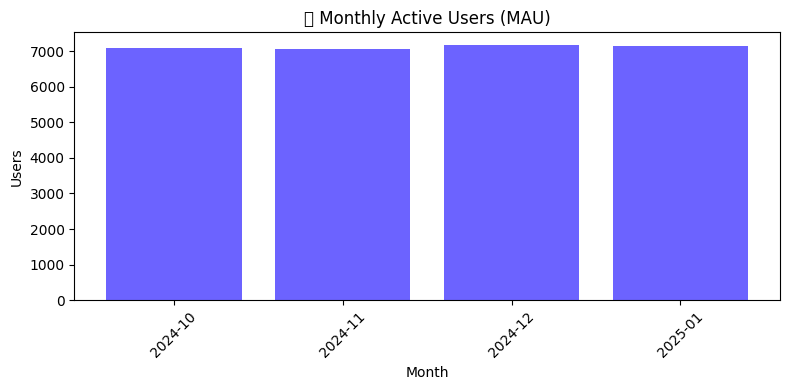

In [21]:
mau = pd.read_sql("""
    SELECT strftime('%Y-%m', session_start) AS month,
           COUNT(DISTINCT user_id) AS mau
    FROM sessions
    GROUP BY month
    ORDER BY month
""", conn)

plt.figure(figsize=(8, 4))
plt.bar(mau["month"], mau["mau"], color="#6C63FF")
plt.title("📈 Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_15073/1678471822.py:18: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


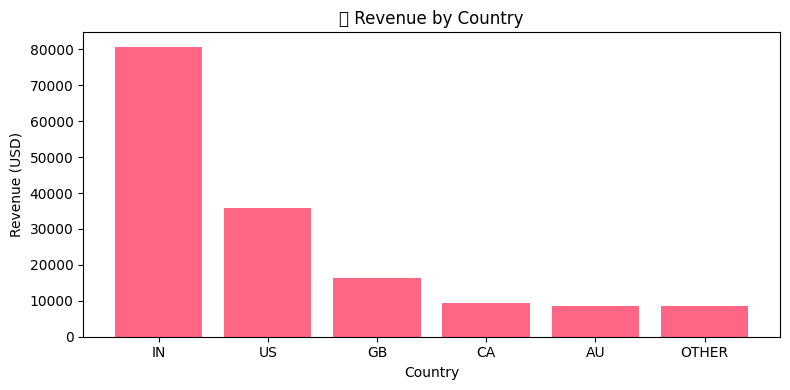

In [22]:
revenue = pd.read_sql("""
    SELECT
        u.country,
        ROUND(SUM(t.amount_usd), 2) AS revenue
    FROM transactions t
    JOIN users u ON t.user_id = u.user_id
    WHERE t.status = 'success'
    GROUP BY u.country
    ORDER BY revenue DESC
    LIMIT 6
""", conn)

plt.figure(figsize=(8, 4))
plt.bar(revenue["country"], revenue["revenue"], color="#FF6584")
plt.title("💰 Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_15073/3996156874.py:14: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


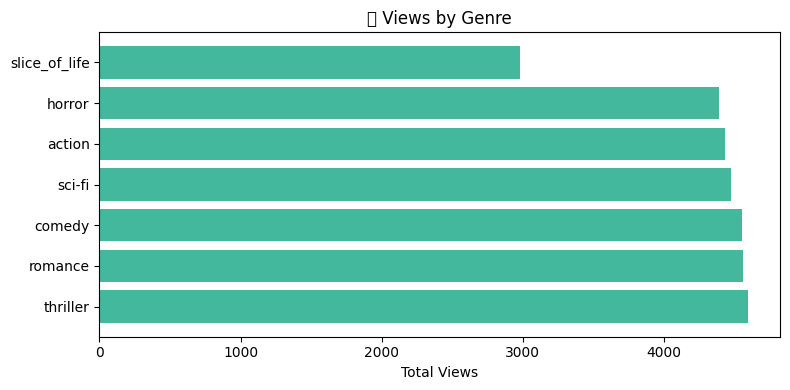

In [23]:
genres = pd.read_sql("""
    SELECT
        genre,
        COUNT(*) AS total_views
    FROM content_views
    GROUP BY genre
    ORDER BY total_views DESC
""", conn)

plt.figure(figsize=(8, 4))
plt.barh(genres["genre"], genres["total_views"], color="#43B89C")
plt.title("🎭 Views by Genre")
plt.xlabel("Total Views")
plt.tight_layout()
plt.show()